# Module 7: Presentation Attack Detection (PAD) — Analysis & Demonstration

| | |
|---|---|
| **Project** | Face Verification Pipeline — AgeDB-30 / LFW |
| **Notebook** | `notebooks/07_PAD_analysis.ipynb` |
| **Date** | 2026-03-21 |
| **Dependencies** | Module 1 (aligned images), Module 2 (embeddings) |
| **Input** | `data/aligned/{agedb,lfw}/*.jpg`, `results/embeddings_arcface_*.npz` |
| **Output** | `notebooks/pad_output/*.png`, `notebooks/pad_output/*.csv` |
| **Reference** | `05_pad_strategy.md` — full architecture specification |

---

## Objective

This module addresses **point (e)** of the recruitment task:

> *How would you react if the dataset contained fake materials reflecting
> presentation attack instruments (face printouts, screen photos, masks, etc.)?*

The full architectural response is documented in `05_pad_strategy.md`.
This notebook provides the **practical, code-backed** complement:

1. **Diagnostic profiling** — Establish the texture/frequency/quality baseline
   of genuine samples in our datasets (LBP, FFT, image quality metrics).
2. **Attack simulation** — Synthesize print, screen-replay, and paper-mask
   attacks on real samples to show how artifacts manifest.
3. **Feature comparison** — Quantify how PAD-relevant features shift between
   genuine and spoofed inputs.
4. **Detector demonstration** — Train a lightweight SVM on LBP + frequency
   features and report ISO 30107-3 metrics (APCER, BPCER, ACER).
5. **Embedding-space analysis** — Show whether spoofed samples cluster
   differently in the ArcFace feature space.

### Attack Taxonomy (ISO/IEC 30107-1)

| Attack Type | Artifact | Simulated Here |
|---|---|---|
| **Print attack** | Inkjet/laser printed photo re-captured by camera | Yes |
| **Screen replay** | Photo displayed on phone/monitor re-captured | Yes |
| **Paper mask** | Printed face with eye holes | Yes (simplified) |
| **3D silicone mask** | Custom-cast mask | No (requires NIR/depth hardware) |
| **Deepfake injection** | GAN-generated face in video stream | No (requires video) |

## 1. Configuration and Imports

In [1]:
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.feature import local_binary_pattern
from sklearn.manifold import TSNE
from sklearn.metrics import auc as sklearn_auc
from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 150,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "figure.facecolor": "white",
    }
)

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path("..").resolve()
ALIGNED_DIR = PROJECT_ROOT / "data" / "aligned"
RESULTS_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "pad_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["agedb", "lfw"]
DS_LABELS = {"agedb": "AgeDB-30", "lfw": "LFW"}

N_SAMPLES = 200

COLORS = {
    "genuine": "#2E7D32",
    "print": "#D32F2F",
    "replay": "#F57C00",
    "mask": "#7B1FA2",
    "primary": "#1976D2",
    "secondary": "#455A64",
}

LBP_RADIUS = 2
LBP_N_POINTS = 8 * LBP_RADIUS
LBP_METHOD = "uniform"
LBP_N_BINS = LBP_N_POINTS + 2

for ds in DATASETS:
    p = ALIGNED_DIR / ds
    if not p.exists():
        raise FileNotFoundError(f"Missing aligned images: {p}")

print(f"Project root : {PROJECT_ROOT}")
print(f"Output dir   : {OUTPUT_DIR}")
print(f"Samples/ds   : {N_SAMPLES}")
print(f"LBP config   : R={LBP_RADIUS}, P={LBP_N_POINTS}, method={LBP_METHOD}")

Project root : /Users/jakub/Desktop/NASK_ZADANIE
Output dir   : /Users/jakub/Desktop/NASK_ZADANIE/notebooks/pad_output
Samples/ds   : 200
LBP config   : R=2, P=16, method=uniform


## 2. Helper Functions

In [2]:
def load_sample_images(dataset, n=N_SAMPLES):
    """Load n random aligned images from a dataset as grayscale + color."""
    img_dir = ALIGNED_DIR / dataset
    all_paths = sorted(img_dir.glob("*.jpg"))
    rng = np.random.default_rng(SEED)
    chosen = rng.choice(len(all_paths), size=min(n, len(all_paths)), replace=False)
    chosen.sort()
    results = []
    for idx in chosen:
        p = all_paths[idx]
        color = cv2.imread(str(p))
        if color is None:
            continue
        color = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(color, cv2.COLOR_RGB2GRAY)
        results.append({"path": p, "color": color, "gray": gray})
    return results


def compute_lbp_histogram(gray_img):
    """Compute normalized LBP histogram for a grayscale image."""
    lbp = local_binary_pattern(gray_img, LBP_N_POINTS, LBP_RADIUS, method=LBP_METHOD)
    hist, _ = np.histogram(lbp.ravel(), bins=LBP_N_BINS, range=(0, LBP_N_BINS), density=True)
    return hist


def compute_frequency_features(gray_img):
    """Compute frequency-domain features from 2D FFT magnitude spectrum."""
    f = np.fft.fft2(gray_img.astype(np.float64))
    fshift = np.fft.fftshift(f)
    magnitude = np.log1p(np.abs(fshift))
    h, w = magnitude.shape
    cy, cx = h // 2, w // 2
    r_low, r_mid, r_high = min(h, w) // 8, min(h, w) // 4, min(h, w) // 2
    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)
    low = magnitude[dist <= r_low].mean()
    mid = magnitude[(dist > r_low) & (dist <= r_mid)].mean()
    high = magnitude[(dist > r_mid) & (dist <= r_high)].mean()
    ratio = high / (low + 1e-10)
    return np.array([low, mid, high, ratio]), magnitude


def compute_quality_metrics(gray_img):
    """Compute image quality metrics relevant to PAD."""
    laplacian_var = cv2.Laplacian(gray_img, cv2.CV_64F).var()
    mean_intensity = gray_img.mean()
    std_intensity = gray_img.std()
    h, w = gray_img.shape
    patch_size = max(h, w) // 4
    patches = []
    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patches.append(gray_img[i : i + patch_size, j : j + patch_size].std())
    local_std_var = np.var(patches) if patches else 0.0
    return {
        "laplacian_var": laplacian_var,
        "mean_intensity": mean_intensity,
        "std_intensity": std_intensity,
        "local_std_var": local_std_var,
    }


def save_fig(fig, name):
    """Save figure to output directory in PNG and PDF."""
    for ext in ["png", "pdf"]:
        path = OUTPUT_DIR / f"{name}.{ext}"
        fig.savefig(path, bbox_inches="tight", facecolor="white")
    print(f"  Saved: {name}.png / .pdf")


print("Helper functions defined.")

Helper functions defined.


## 3. Load Genuine Samples

In [3]:
genuine = {}
for ds in DATASETS:
    genuine[ds] = load_sample_images(ds, N_SAMPLES)
    print(f"  {DS_LABELS[ds]}: loaded {len(genuine[ds])} images")

print(f"\nTotal genuine samples: {sum(len(v) for v in genuine.values())}")

  AgeDB-30: loaded 200 images


  LFW: loaded 200 images

Total genuine samples: 400


---

## 4. Attack Simulation

Since LFW and AgeDB do not contain intentional presentation attacks,
we **synthesize** three types of attack artifacts on the genuine samples.
These simulations model the degradation pipeline:

**Real face → Artifact creation → Re-capture by camera**

### 4.1 Print Attack Simulation

Models the pipeline: *photo → inkjet printer → paper → re-photographed by camera*.

Artifacts introduced:
- **Halftone dot pattern** (printer rasterization)
- **Color gamut reduction** (printer gamut narrower than skin reflectance)
- **Gaussian blur** (paper fiber scattering + re-capture defocus)
- **Additive noise** (paper texture)

### 4.2 Screen Replay Attack Simulation

Models the pipeline: *photo → displayed on screen → re-photographed by camera*.

Artifacts introduced:
- **Moiré interference pattern** (screen pixel grid × camera sensor grid)
- **Color temperature shift** (display backlight differs from ambient)
- **Reduced contrast** (screen brightness limits dynamic range)
- **Slight blur** (re-capture defocus)

### 4.3 Paper Mask Attack Simulation

Models: *photo → printed → cut out → held in front of camera*.

Artifacts introduced:
- All print attack artifacts
- **Edge artifacts** (visible paper boundary / cutout edges)
- **Flat depth cues** (uniform blur across face)

In [4]:
def simulate_print_attack(color_img):
    """Simulate re-captured printed photograph."""
    img = color_img.astype(np.float64) / 255.0
    img = img * 0.85 + 0.05
    h, w = img.shape[:2]
    yy, xx = np.mgrid[0:h, 0:w]
    halftone = 0.02 * np.sin(2 * np.pi * xx / 3.0) * np.sin(2 * np.pi * yy / 3.0)
    img += halftone[:, :, np.newaxis]
    noise = np.random.normal(0, 0.015, img.shape)
    img += noise
    img = cv2.GaussianBlur(img, (3, 3), 0.8)
    return np.clip(img * 255, 0, 255).astype(np.uint8)


def simulate_replay_attack(color_img):
    """Simulate re-captured screen display."""
    img = color_img.astype(np.float64) / 255.0
    img = img * 0.80 + 0.08
    h, w = img.shape[:2]
    yy, xx = np.mgrid[0:h, 0:w]
    moire_freq = 12.0
    moire = 0.03 * np.sin(2 * np.pi * xx / moire_freq)
    moire += 0.02 * np.sin(2 * np.pi * yy / (moire_freq * 0.8))
    img += moire[:, :, np.newaxis]
    img[:, :, 2] = img[:, :, 2] * 1.08
    img[:, :, 0] = img[:, :, 0] * 0.95
    img = cv2.GaussianBlur(img, (3, 3), 0.5)
    return np.clip(img * 255, 0, 255).astype(np.uint8)


def simulate_mask_attack(color_img):
    """Simulate paper mask (printed cutout held in front of camera)."""
    img = simulate_print_attack(color_img).astype(np.float64) / 255.0
    h, w = img.shape[:2]
    cy, cx = h // 2, w // 2
    ry, rx = int(h * 0.42), int(w * 0.40)
    yy, xx = np.mgrid[0:h, 0:w]
    ellipse = ((yy - cy) / ry) ** 2 + ((xx - cx) / rx) ** 2
    edge_band = (ellipse > 0.85) & (ellipse < 1.15)
    outside = ellipse >= 1.15
    edge_noise = np.random.normal(0, 0.06, img.shape)
    img[edge_band] += edge_noise[edge_band]
    bg_color = np.array([0.75, 0.72, 0.68])
    alpha = np.clip((ellipse[outside] - 1.15) / 0.3, 0, 1)
    for c in range(3):
        ch = img[:, :, c]
        vals = ch[outside]
        ch[outside] = vals * (1 - alpha) + bg_color[c] * alpha
    img = cv2.GaussianBlur(img, (5, 5), 1.2)
    return np.clip(img * 255, 0, 255).astype(np.uint8)


ATTACK_FUNCS = {
    "print": simulate_print_attack,
    "replay": simulate_replay_attack,
    "mask": simulate_mask_attack,
}
ATTACK_LABELS = {
    "print": "Print Attack",
    "replay": "Screen Replay",
    "mask": "Paper Mask",
}

print("Attack simulation functions defined.")
print(f"Attack types: {list(ATTACK_LABELS.values())}")

Attack simulation functions defined.
Attack types: ['Print Attack', 'Screen Replay', 'Paper Mask']


### 4.4 Visual Examples — Genuine vs. Simulated Attacks

  Saved: attack_examples.png / .pdf


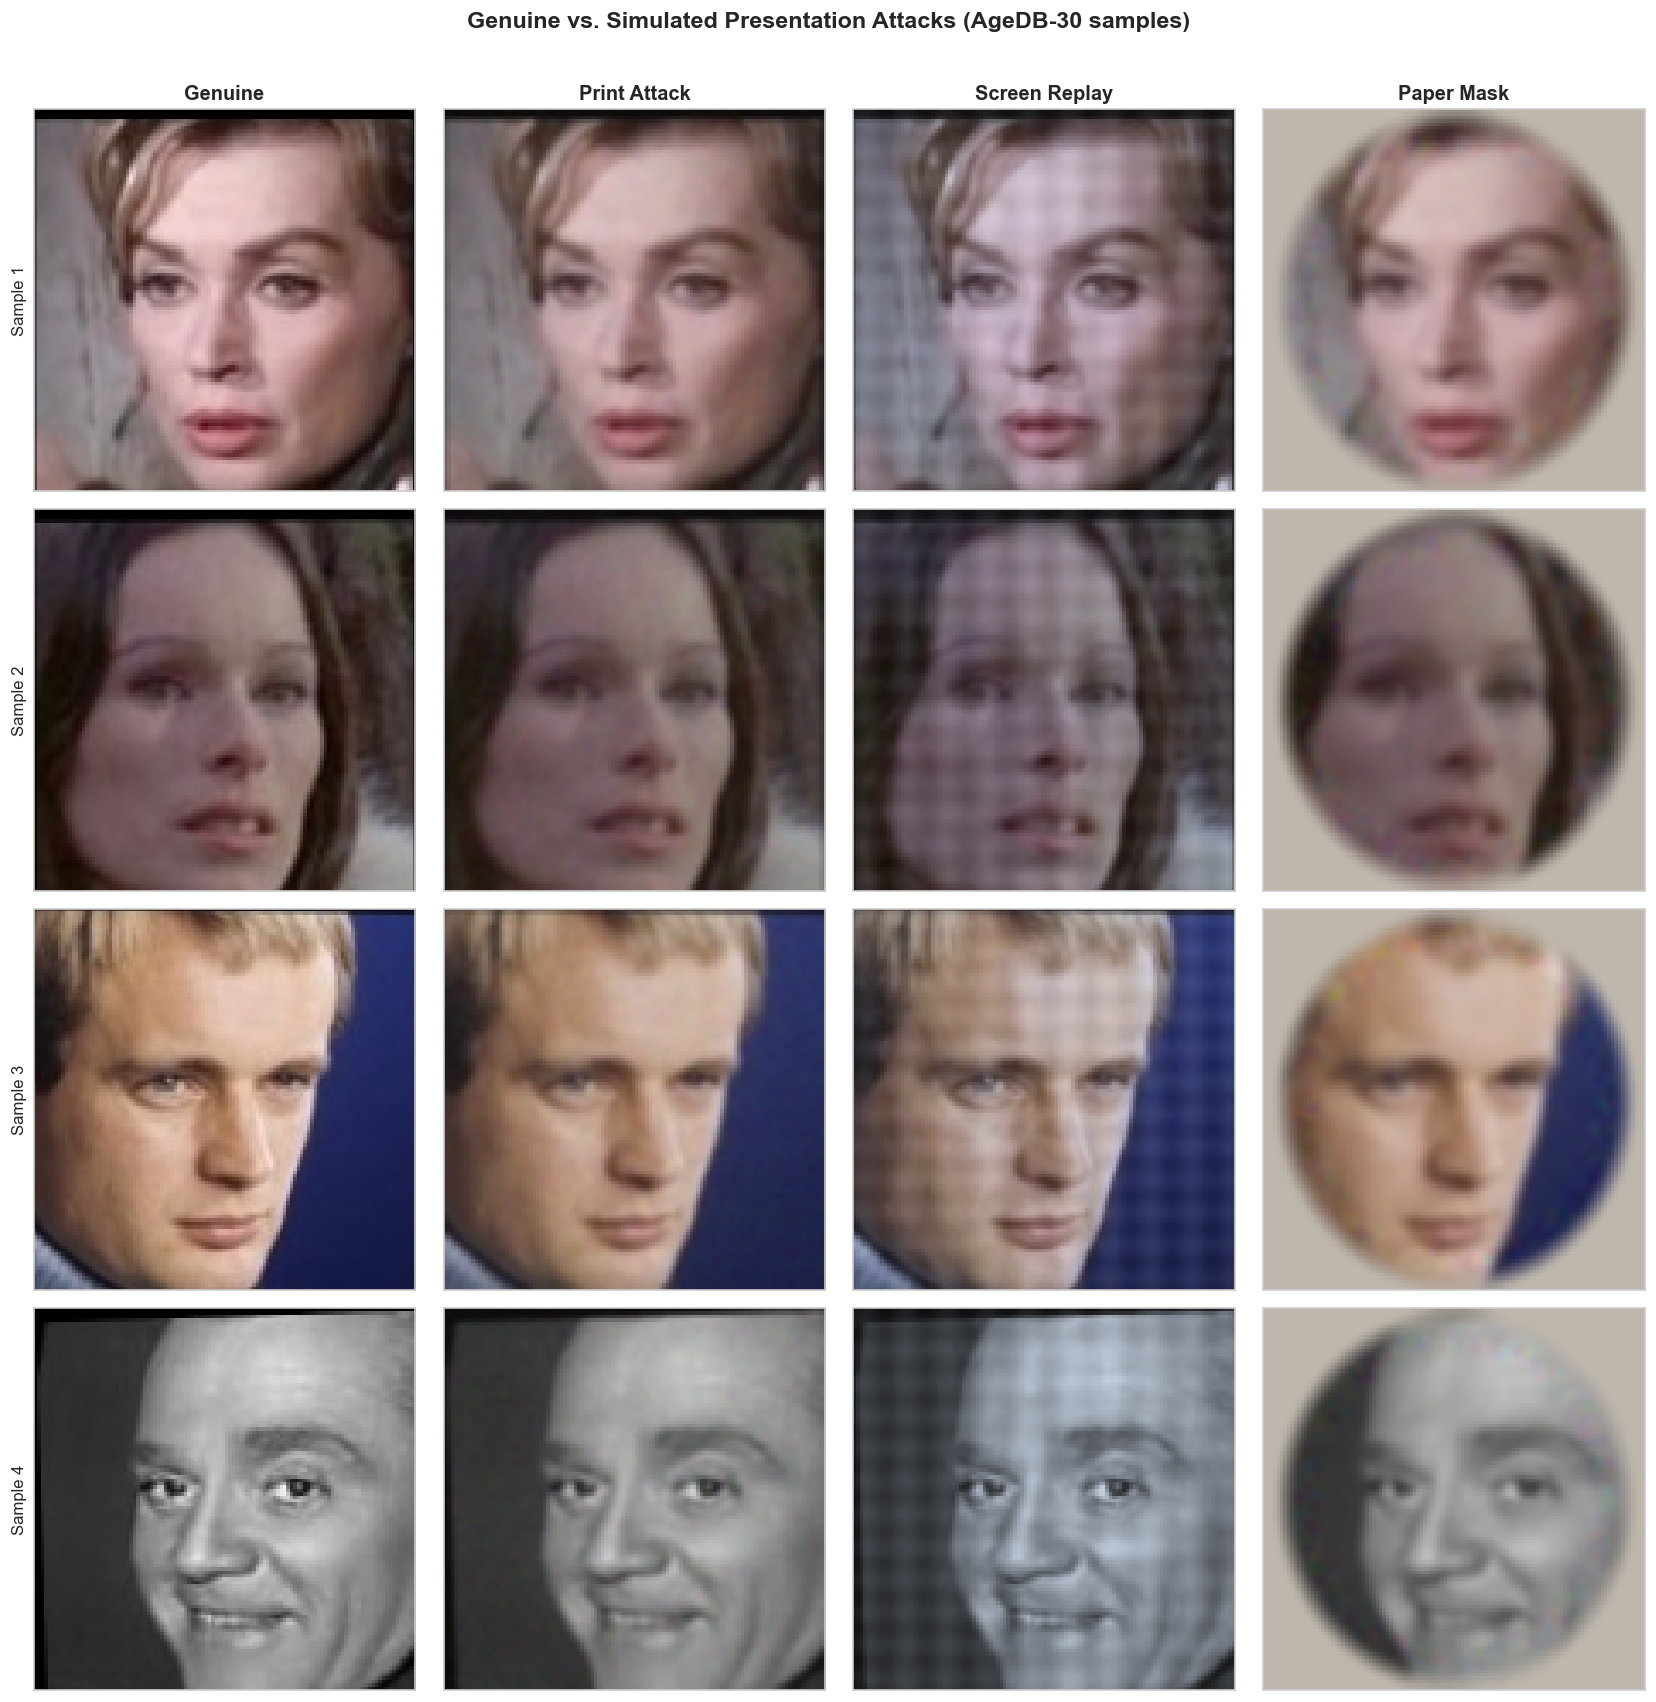

In [5]:
n_examples = 4
fig, axes = plt.subplots(n_examples, 4, figsize=(14, 3.5 * n_examples))

sample_imgs = genuine["agedb"][:n_examples]

col_titles = ["Genuine", "Print Attack", "Screen Replay", "Paper Mask"]
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=12, fontweight="bold")

for i, sample in enumerate(sample_imgs):
    axes[i, 0].imshow(sample["color"])
    axes[i, 0].set_ylabel(f"Sample {i + 1}", fontsize=10)
    for j, atk_key in enumerate(["print", "replay", "mask"]):
        attacked = ATTACK_FUNCS[atk_key](sample["color"])
        axes[i, j + 1].imshow(attacked)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Genuine vs. Simulated Presentation Attacks (AgeDB-30 samples)", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
save_fig(fig, "attack_examples")
plt.show()

---

## 5. Feature Extraction — Genuine Baseline vs. Attacks

For each image (genuine and attacked), we extract three feature families:

1. **LBP histogram** (18 bins) — texture micro-patterns; print/screen attacks
   alter the local texture statistics (halftone dots, moiré).
2. **Frequency band energies** (4 features) — low/mid/high frequency energy
   and high-to-low ratio from 2D FFT; spoofed inputs show characteristic
   frequency peaks.
3. **Quality metrics** (4 features) — Laplacian variance (sharpness),
   intensity statistics, local contrast variance.

In [6]:
def extract_all_features(color_img, gray_img):
    """Extract combined PAD feature vector from an image."""
    lbp_hist = compute_lbp_histogram(gray_img)
    freq_feats, _ = compute_frequency_features(gray_img)
    qm = compute_quality_metrics(gray_img)
    quality_vec = np.array([qm["laplacian_var"], qm["mean_intensity"], qm["std_intensity"], qm["local_std_var"]])
    return np.concatenate([lbp_hist, freq_feats, quality_vec])


all_features = []
all_labels = []
all_datasets = []
all_types = []

for ds in DATASETS:
    print(f"Processing {DS_LABELS[ds]}...")
    for sample in genuine[ds]:
        feat = extract_all_features(sample["color"], sample["gray"])
        all_features.append(feat)
        all_labels.append(0)
        all_datasets.append(ds)
        all_types.append("genuine")

        for atk_key, atk_func in ATTACK_FUNCS.items():
            attacked_color = atk_func(sample["color"])
            attacked_gray = cv2.cvtColor(attacked_color, cv2.COLOR_RGB2GRAY)
            feat_atk = extract_all_features(attacked_color, attacked_gray)
            all_features.append(feat_atk)
            all_labels.append(1)
            all_datasets.append(ds)
            all_types.append(atk_key)

X = np.array(all_features)
y = np.array(all_labels)
ds_arr = np.array(all_datasets)
type_arr = np.array(all_types)

n_genuine = (y == 0).sum()
n_attack = (y == 1).sum()
print(f"\nFeature matrix: {X.shape}")
print(
    f"Genuine: {n_genuine}, Attacks: {n_attack} "
    f"(print: {(type_arr == 'print').sum()}, "
    f"replay: {(type_arr == 'replay').sum()}, "
    f"mask: {(type_arr == 'mask').sum()})"
)

Processing AgeDB-30...


Processing LFW...



Feature matrix: (1600, 26)
Genuine: 400, Attacks: 1200 (print: 400, replay: 400, mask: 400)


---

## 6. Diagnostic Visualization — LBP Texture Profiles

  Saved: lbp_profiles.png / .pdf


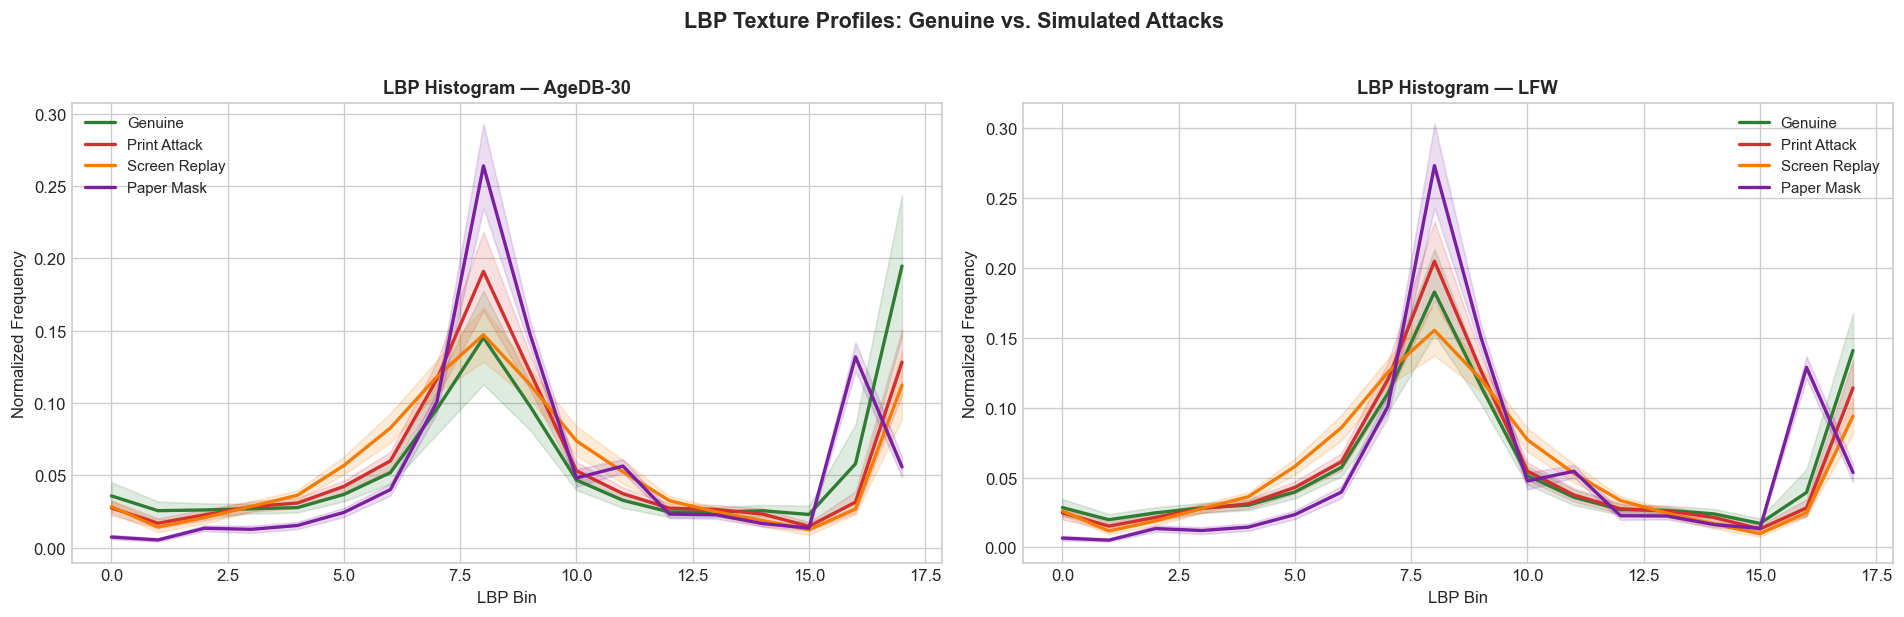

In [7]:
lbp_slice = slice(0, LBP_N_BINS)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_idx, ds in enumerate(DATASETS):
    ax = axes[ax_idx]
    ds_mask = ds_arr == ds

    for tkey, label, color in [
        ("genuine", "Genuine", COLORS["genuine"]),
        ("print", "Print Attack", COLORS["print"]),
        ("replay", "Screen Replay", COLORS["replay"]),
        ("mask", "Paper Mask", COLORS["mask"]),
    ]:
        mask = ds_mask & (type_arr == tkey)
        lbp_data = X[mask][:, lbp_slice]
        mean_hist = lbp_data.mean(axis=0)
        std_hist = lbp_data.std(axis=0)
        bins = np.arange(LBP_N_BINS)
        ax.plot(bins, mean_hist, label=label, color=color, lw=2)
        ax.fill_between(bins, mean_hist - std_hist, mean_hist + std_hist, alpha=0.15, color=color)

    ax.set_title(f"LBP Histogram — {DS_LABELS[ds]}", fontweight="bold")
    ax.set_xlabel("LBP Bin")
    ax.set_ylabel("Normalized Frequency")
    ax.legend(fontsize=9)

fig.suptitle("LBP Texture Profiles: Genuine vs. Simulated Attacks", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "lbp_profiles")
plt.show()

## 7. Diagnostic Visualization — Frequency Domain

  Saved: frequency_analysis.png / .pdf


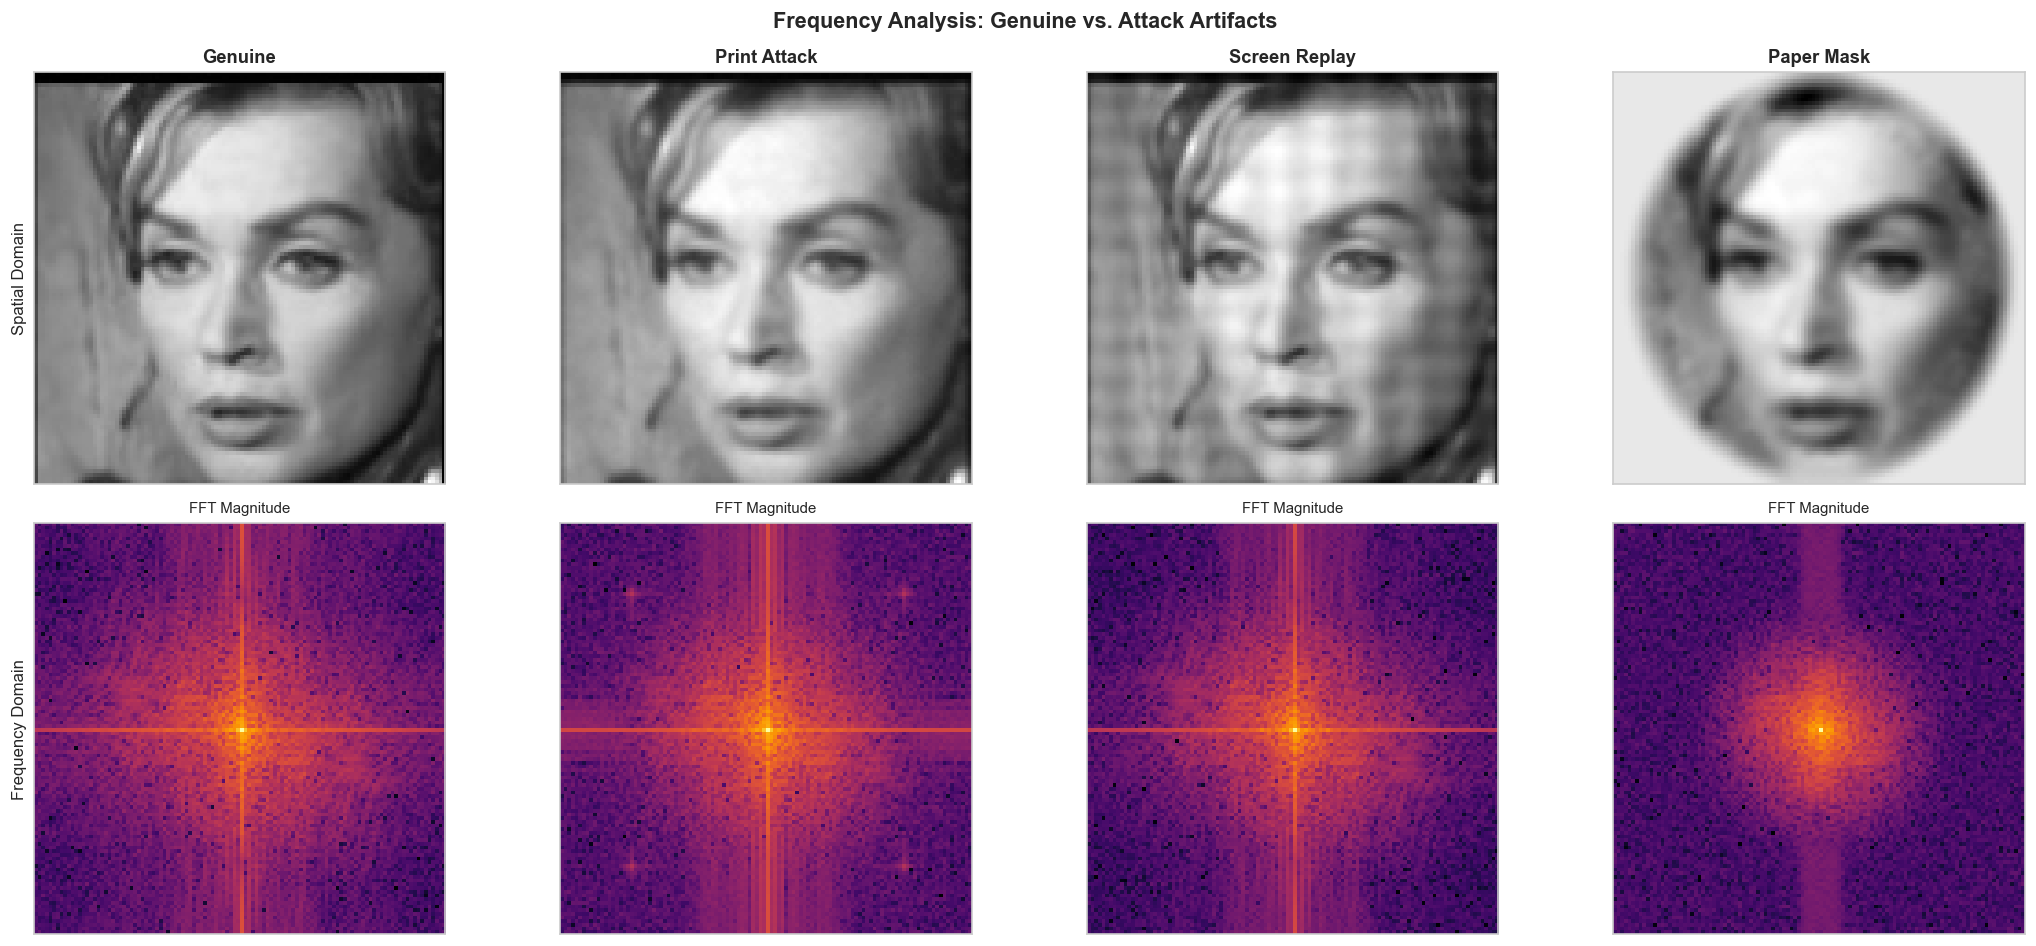

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

demo_sample = genuine["agedb"][0]
demo_imgs = {
    "Genuine": demo_sample["gray"],
    "Print Attack": cv2.cvtColor(simulate_print_attack(demo_sample["color"]), cv2.COLOR_RGB2GRAY),
    "Screen Replay": cv2.cvtColor(simulate_replay_attack(demo_sample["color"]), cv2.COLOR_RGB2GRAY),
    "Paper Mask": cv2.cvtColor(simulate_mask_attack(demo_sample["color"]), cv2.COLOR_RGB2GRAY),
}

for j, (title, gray_img) in enumerate(demo_imgs.items()):
    axes[0, j].imshow(gray_img, cmap="gray")
    axes[0, j].set_title(title, fontweight="bold")
    axes[0, j].set_xticks([])
    axes[0, j].set_yticks([])

    _, mag = compute_frequency_features(gray_img)
    im = axes[1, j].imshow(mag, cmap="inferno")
    axes[1, j].set_title("FFT Magnitude", fontsize=9)
    axes[1, j].set_xticks([])
    axes[1, j].set_yticks([])

axes[0, 0].set_ylabel("Spatial Domain", fontsize=10)
axes[1, 0].set_ylabel("Frequency Domain", fontsize=10)

fig.suptitle("Frequency Analysis: Genuine vs. Attack Artifacts", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "frequency_analysis")
plt.show()

## 8. Diagnostic Visualization — Image Quality Metrics

  Saved: quality_metrics.png / .pdf


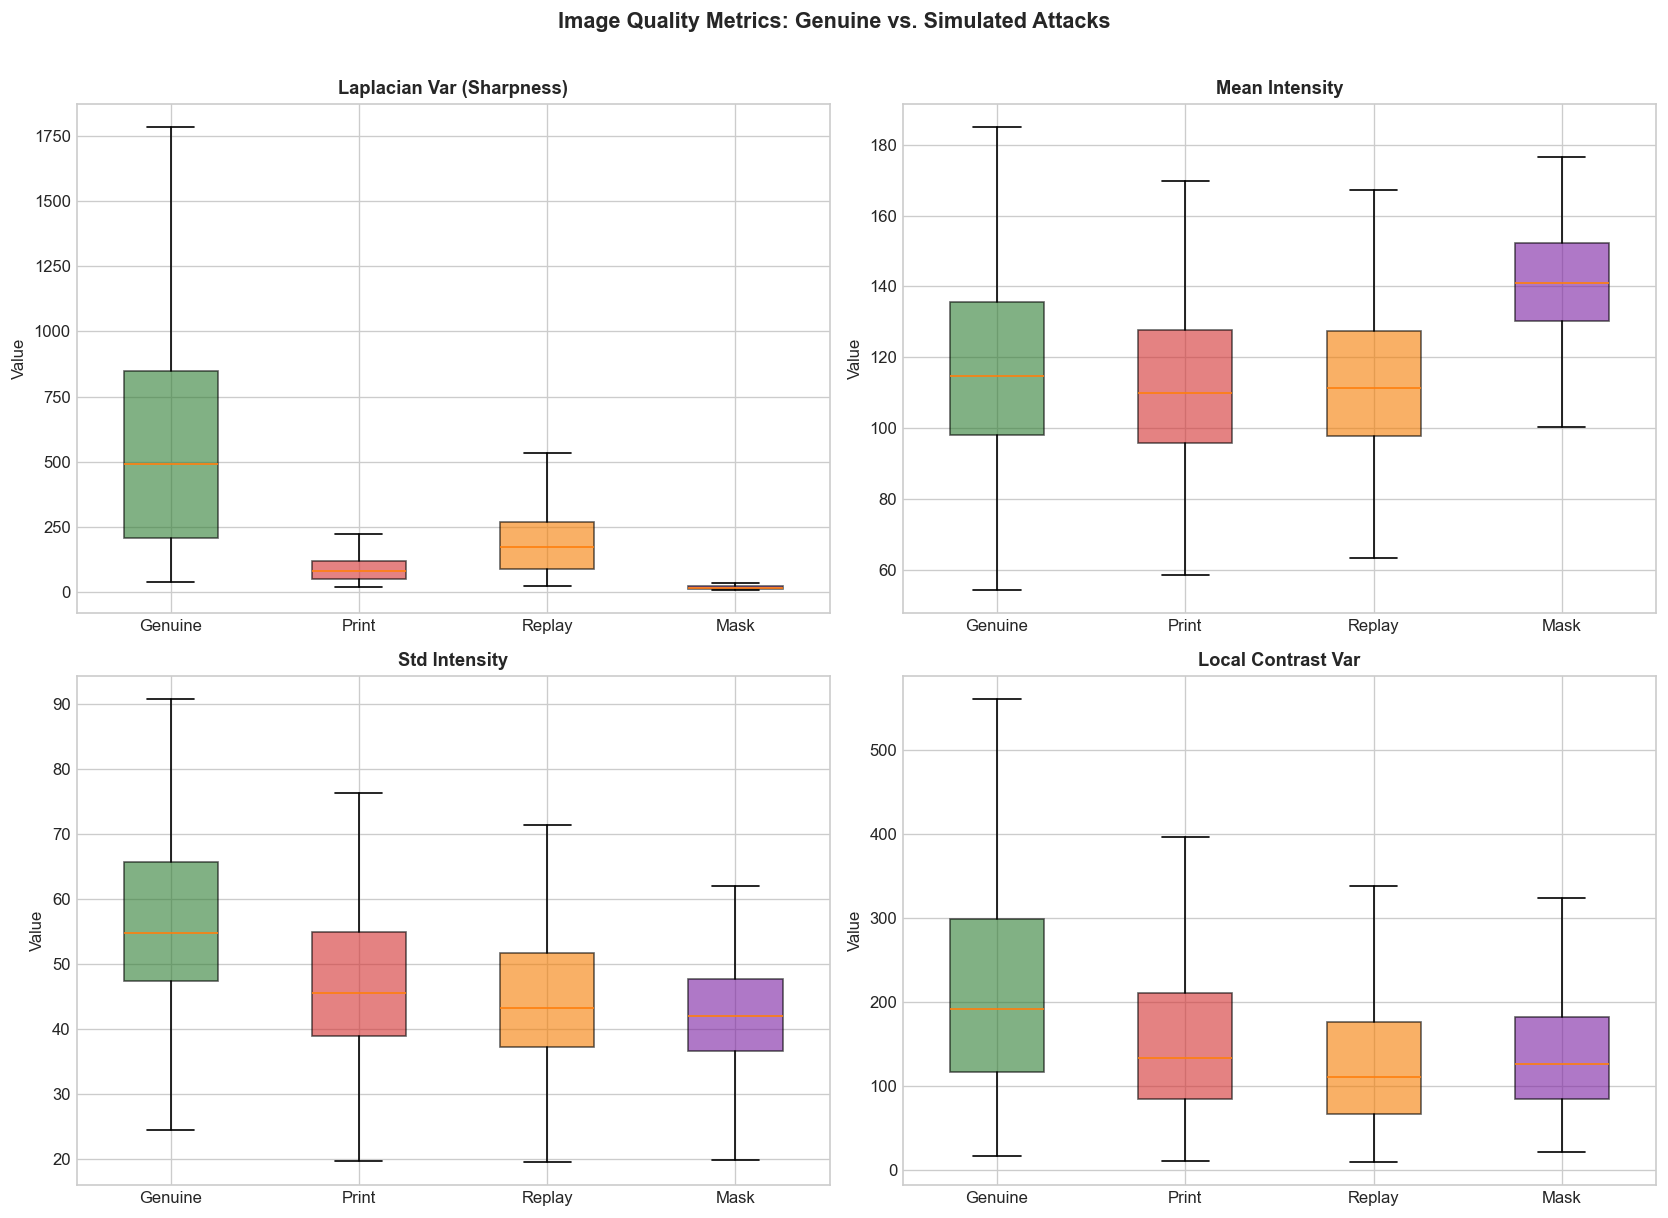

In [9]:
quality_names = ["Laplacian Var (Sharpness)", "Mean Intensity", "Std Intensity", "Local Contrast Var"]
quality_slice = slice(LBP_N_BINS + 4, LBP_N_BINS + 8)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.ravel()

type_keys = ["genuine", "print", "replay", "mask"]
type_labels = ["Genuine", "Print", "Replay", "Mask"]
type_colors = [COLORS[k] for k in type_keys]

for q_idx in range(4):
    ax = axes_flat[q_idx]
    col_idx = LBP_N_BINS + 4 + q_idx
    data_per_type = []
    for tkey in type_keys:
        mask = type_arr == tkey
        data_per_type.append(X[mask, col_idx])

    bplot = ax.boxplot(data_per_type, labels=type_labels, patch_artist=True, widths=0.5, showfliers=False)
    for patch, color in zip(bplot["boxes"], type_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(quality_names[q_idx], fontweight="bold")
    ax.set_ylabel("Value")

fig.suptitle("Image Quality Metrics: Genuine vs. Simulated Attacks", fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
save_fig(fig, "quality_metrics")
plt.show()

## 9. Frequency Band Energy Comparison

  Saved: frequency_bands.png / .pdf


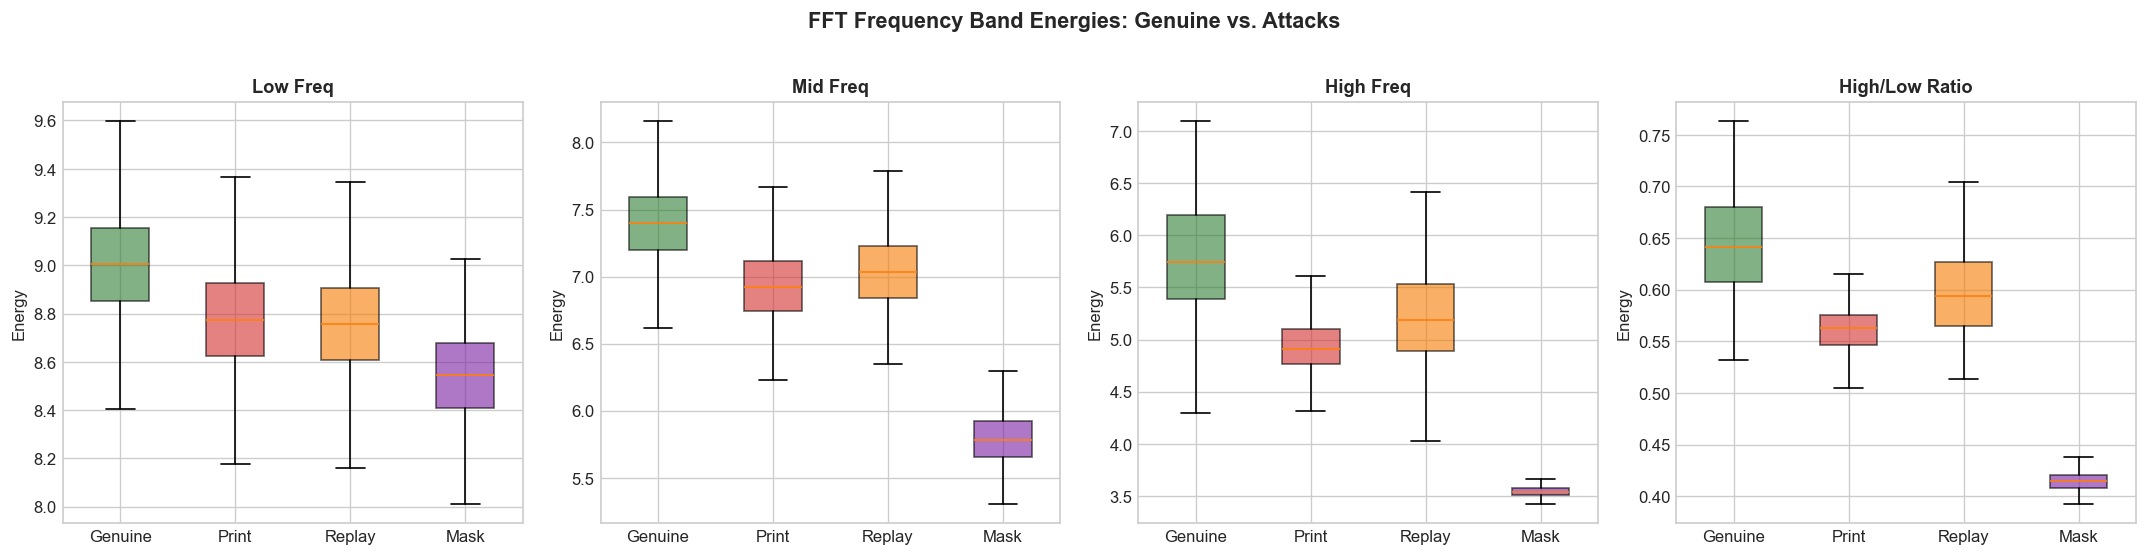

In [10]:
freq_slice = slice(LBP_N_BINS, LBP_N_BINS + 4)
freq_names = ["Low Freq", "Mid Freq", "High Freq", "High/Low Ratio"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for f_idx in range(4):
    ax = axes[f_idx]
    col_idx = LBP_N_BINS + f_idx
    data_per_type = []
    for tkey in type_keys:
        mask = type_arr == tkey
        data_per_type.append(X[mask, col_idx])

    bplot = ax.boxplot(data_per_type, labels=type_labels, patch_artist=True, widths=0.5, showfliers=False)
    for patch, color in zip(bplot["boxes"], type_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(freq_names[f_idx], fontweight="bold")
    ax.set_ylabel("Energy")

fig.suptitle("FFT Frequency Band Energies: Genuine vs. Attacks", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "frequency_bands")
plt.show()

---

## 10. PAD Classifier — SVM on LBP + Frequency + Quality Features

Following the multi-tier architecture from `05_pad_strategy.md`, we demonstrate
a **Tier 1 / Tier 2 equivalent**: a lightweight SVM classifier trained on
hand-crafted features (LBP + FFT + quality). This represents the type of
model that could run on-device or server-side with minimal latency.

We evaluate using **5-fold stratified cross-validation** and report the
ISO/IEC 30107-3 metrics:

- **APCER** — Attack Presentation Classification Error Rate (attacks misclassified as genuine)
- **BPCER** — Bona Fide Presentation Classification Error Rate (genuine misclassified as attack)
- **ACER** — Average Classification Error Rate = (APCER + BPCER) / 2

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

svm = SVC(kernel="rbf", C=10.0, gamma="scale", probability=True, random_state=SEED)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_pred = cross_val_predict(svm, X_scaled, y, cv=cv)
y_prob = cross_val_predict(svm, X_scaled, y, cv=cv, method="predict_proba")[:, 1]

cm = confusion_matrix(y, y_pred)
tn, fp, fn, tp = cm.ravel()

apcer = fp / (fp + tn) if (fp + tn) > 0 else 0.0
bpcer = fn / (fn + tp) if (fn + tp) > 0 else 0.0
acer = (apcer + bpcer) / 2.0

accuracy = (tp + tn) / (tp + tn + fp + fn)

fpr_roc, tpr_roc, _ = roc_curve(y, y_prob)
roc_auc = sklearn_auc(fpr_roc, tpr_roc)

print("=" * 60)
print("PAD Classifier Results (5-fold CV, SVM RBF)")
print("=" * 60)
print(f"  Accuracy : {accuracy:.4f}")
print(f"  APCER    : {apcer:.4f}  (attack presentations incorrectly accepted)")
print(f"  BPCER    : {bpcer:.4f}  (genuine presentations incorrectly rejected)")
print(f"  ACER     : {acer:.4f}  (average classification error)")
print(f"  AUC      : {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")

PAD Classifier Results (5-fold CV, SVM RBF)
  Accuracy : 0.9544
  APCER    : 0.1250  (attack presentations incorrectly accepted)
  BPCER    : 0.0192  (genuine presentations incorrectly rejected)
  ACER     : 0.0721  (average classification error)
  AUC      : 0.9792

Confusion Matrix:
  TN=350  FP=50
  FN=23  TP=1177


### 10.1 Per-Attack-Type APCER

ISO 30107-3 requires reporting APCER **separately for each PAI species**.
The overall APCER is the **maximum** across all species:

$$\text{APCER}_{\text{overall}} = \max_j \left( \text{APCER}_j \right)$$

In [12]:
per_attack_metrics = []
for atk_key in ATTACK_FUNCS:
    atk_mask = type_arr == atk_key
    y_true_atk = y[atk_mask]
    y_pred_atk = y_pred[atk_mask]
    n_total = y_true_atk.sum()
    n_missed = ((y_true_atk == 1) & (y_pred_atk == 0)).sum()
    apcer_j = n_missed / n_total if n_total > 0 else 0.0
    per_attack_metrics.append(
        {
            "Attack Type": ATTACK_LABELS[atk_key],
            "N_samples": int(n_total),
            "N_missed": int(n_missed),
            "APCER": apcer_j,
        }
    )

gen_mask = type_arr == "genuine"
y_true_gen = y[gen_mask]
y_pred_gen = y_pred[gen_mask]
n_gen_total = (y_true_gen == 0).sum()
n_gen_rejected = ((y_true_gen == 0) & (y_pred_gen == 1)).sum()
bpcer_val = n_gen_rejected / n_gen_total if n_gen_total > 0 else 0.0

df_per_attack = pd.DataFrame(per_attack_metrics)
apcer_overall = df_per_attack["APCER"].max()
acer_overall = (apcer_overall + bpcer_val) / 2.0

df_per_attack.loc[len(df_per_attack)] = {
    "Attack Type": "OVERALL (max)",
    "N_samples": df_per_attack["N_samples"].sum(),
    "N_missed": df_per_attack["N_missed"].sum(),
    "APCER": apcer_overall,
}

print(f"\nBPCER (bona fide): {bpcer_val:.4f}")
print(f"ACER (overall):    {acer_overall:.4f}\n")
print(df_per_attack.to_string(index=False))

df_per_attack.to_csv(OUTPUT_DIR / "per_attack_apcer.csv", index=False)
print("\n  Saved: per_attack_apcer.csv")


BPCER (bona fide): 0.1250
ACER (overall):    0.0825

  Attack Type  N_samples  N_missed  APCER
 Print Attack        400        16 0.0400
Screen Replay        400         7 0.0175
   Paper Mask        400         0 0.0000
OVERALL (max)       1200        23 0.0400

  Saved: per_attack_apcer.csv


### 10.2 ROC Curve and Confusion Matrix

  Saved: pad_roc_confusion.png / .pdf


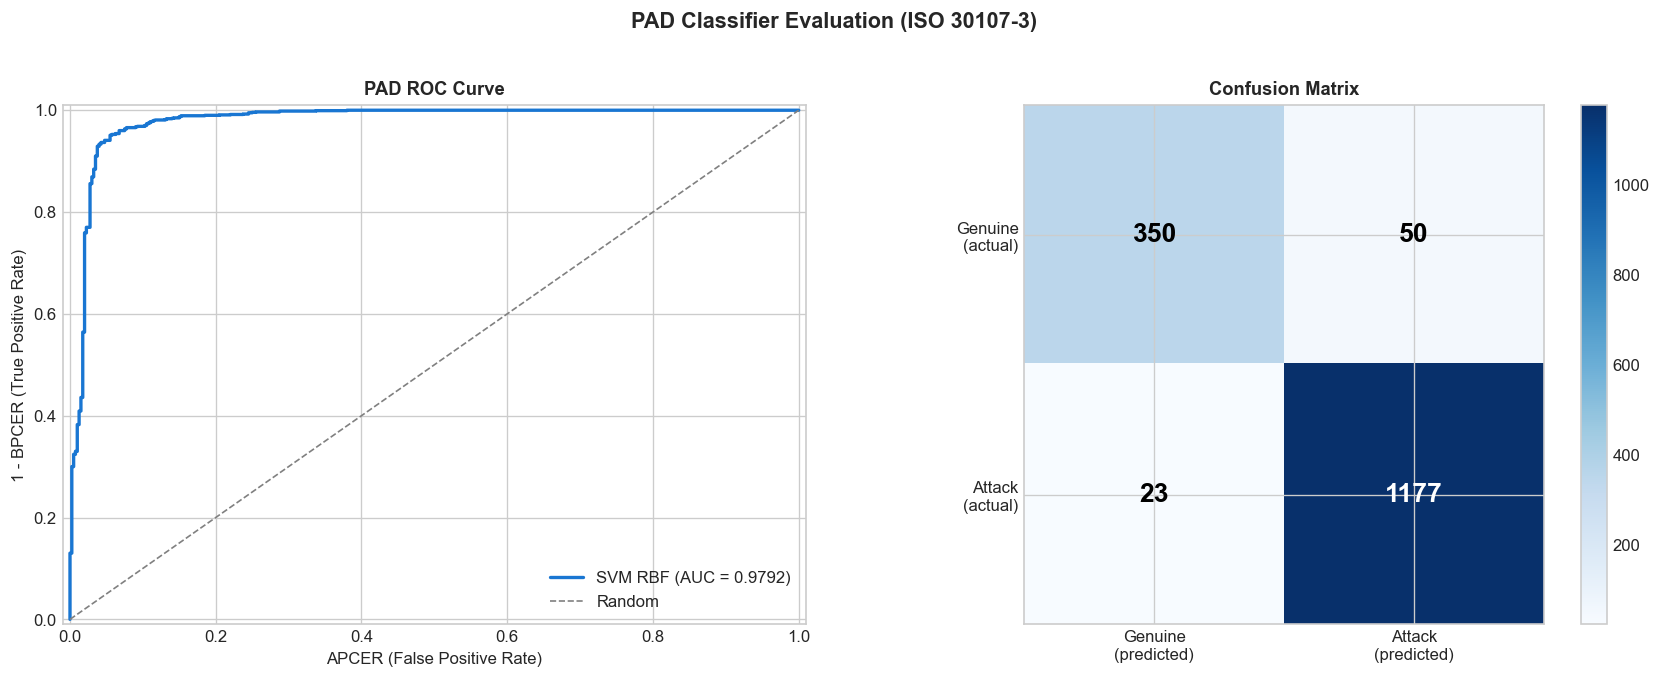

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

ax1.plot(fpr_roc, tpr_roc, color=COLORS["primary"], lw=2, label=f"SVM RBF (AUC = {roc_auc:.4f})")
ax1.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Random")
ax1.set_xlabel("APCER (False Positive Rate)")
ax1.set_ylabel("1 - BPCER (True Positive Rate)")
ax1.set_title("PAD ROC Curve", fontweight="bold")
ax1.legend(loc="lower right")
ax1.set_xlim([-0.01, 1.01])
ax1.set_ylim([-0.01, 1.01])

cm_display = np.array([[tn, fp], [fn, tp]])
im = ax2.imshow(cm_display, cmap="Blues", interpolation="nearest")
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(["Genuine\n(predicted)", "Attack\n(predicted)"])
ax2.set_yticklabels(["Genuine\n(actual)", "Attack\n(actual)"])
ax2.set_title("Confusion Matrix", fontweight="bold")
for i in range(2):
    for j in range(2):
        val = cm_display[i, j]
        color = "white" if val > cm_display.max() / 2 else "black"
        ax2.text(j, i, str(val), ha="center", va="center", fontsize=16, fontweight="bold", color=color)
plt.colorbar(im, ax=ax2, fraction=0.046)

fig.suptitle("PAD Classifier Evaluation (ISO 30107-3)", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "pad_roc_confusion")
plt.show()

---

## 11. Embedding-Space Analysis — Do Spoofs Cluster Differently?

We investigate whether simulated attacks produce embeddings that cluster
separately from genuine faces in the ArcFace feature space. If they do,
the face recognition model itself provides some implicit PAD capability.
If they do not, it confirms that a **dedicated PAD module is essential**
(as argued in `05_pad_strategy.md`).

In [14]:
emb_file = RESULTS_DIR / "embeddings_arcface_agedb.npz"
if not emb_file.exists():
    print(f"WARNING: {emb_file} not found. Skipping embedding analysis.")
else:
    emb_data = np.load(emb_file)
    emb_keys = list(emb_data.keys())
    print(f"Embedding file keys: {emb_keys}")
    print(f"First key shape: {emb_data[emb_keys[0]].shape}")

Embedding file keys: ['embeddings', 'paths', 'model_name', 'dataset']
First key shape: (12000, 512)


In [15]:
try:
    from insightface.app import FaceAnalysis

    HAS_INSIGHTFACE = True
except ImportError:
    HAS_INSIGHTFACE = False

if emb_file.exists() and HAS_INSIGHTFACE:
    print("Loading ArcFace model for embedding extraction...")
    app = FaceAnalysis(name="buffalo_l", providers=["CPUExecutionProvider"])
    app.prepare(ctx_id=-1, det_size=(112, 112))

    rec_model = None
    for m in app.models.values():
        if hasattr(m, "get_feat"):
            rec_model = m
            break

    if rec_model is None:
        print("WARNING: Could not find recognition model in InsightFace app.")
    else:
        n_emb_samples = 50
        emb_samples = genuine["agedb"][:n_emb_samples]

        emb_list = []
        emb_type_list = []

        for sample in emb_samples:
            img_bgr = cv2.cvtColor(sample["color"], cv2.COLOR_RGB2BGR)
            blob = cv2.dnn.blobFromImage(img_bgr, 1.0 / 127.5, (112, 112), (127.5, 127.5, 127.5), swapRB=True)
            feat = rec_model.session.run(
                [rec_model.session.get_outputs()[0].name], {rec_model.session.get_inputs()[0].name: blob}
            )[0].flatten()
            feat = feat / (np.linalg.norm(feat) + 1e-10)
            emb_list.append(feat)
            emb_type_list.append("genuine")

            for atk_key, atk_func in ATTACK_FUNCS.items():
                attacked = atk_func(sample["color"])
                atk_bgr = cv2.cvtColor(attacked, cv2.COLOR_RGB2BGR)
                blob_a = cv2.dnn.blobFromImage(atk_bgr, 1.0 / 127.5, (112, 112), (127.5, 127.5, 127.5), swapRB=True)
                feat_a = rec_model.session.run(
                    [rec_model.session.get_outputs()[0].name], {rec_model.session.get_inputs()[0].name: blob_a}
                )[0].flatten()
                feat_a = feat_a / (np.linalg.norm(feat_a) + 1e-10)
                emb_list.append(feat_a)
                emb_type_list.append(atk_key)

        emb_matrix = np.array(emb_list)
        emb_types = np.array(emb_type_list)
        print(f"Embedding matrix: {emb_matrix.shape}")
        print(f"Types: {dict(zip(*np.unique(emb_types, return_counts=True)))}")

elif not HAS_INSIGHTFACE:
    print("InsightFace not available. Skipping embedding extraction for attacks.")
    emb_matrix = None
else:
    print("Embedding file not found. Skipping.")
    emb_matrix = None

Loading ArcFace model for embedding extraction...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


find model: /Users/jakub/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/jakub/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/jakub/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/jakub/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/jakub/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (112, 112)


Embedding matrix: (200, 512)
Types: {np.str_('genuine'): np.int64(50), np.str_('mask'): np.int64(50), np.str_('print'): np.int64(50), np.str_('replay'): np.int64(50)}


Running t-SNE on embeddings (genuine + attacks)...


  Saved: embedding_attack_analysis.png / .pdf


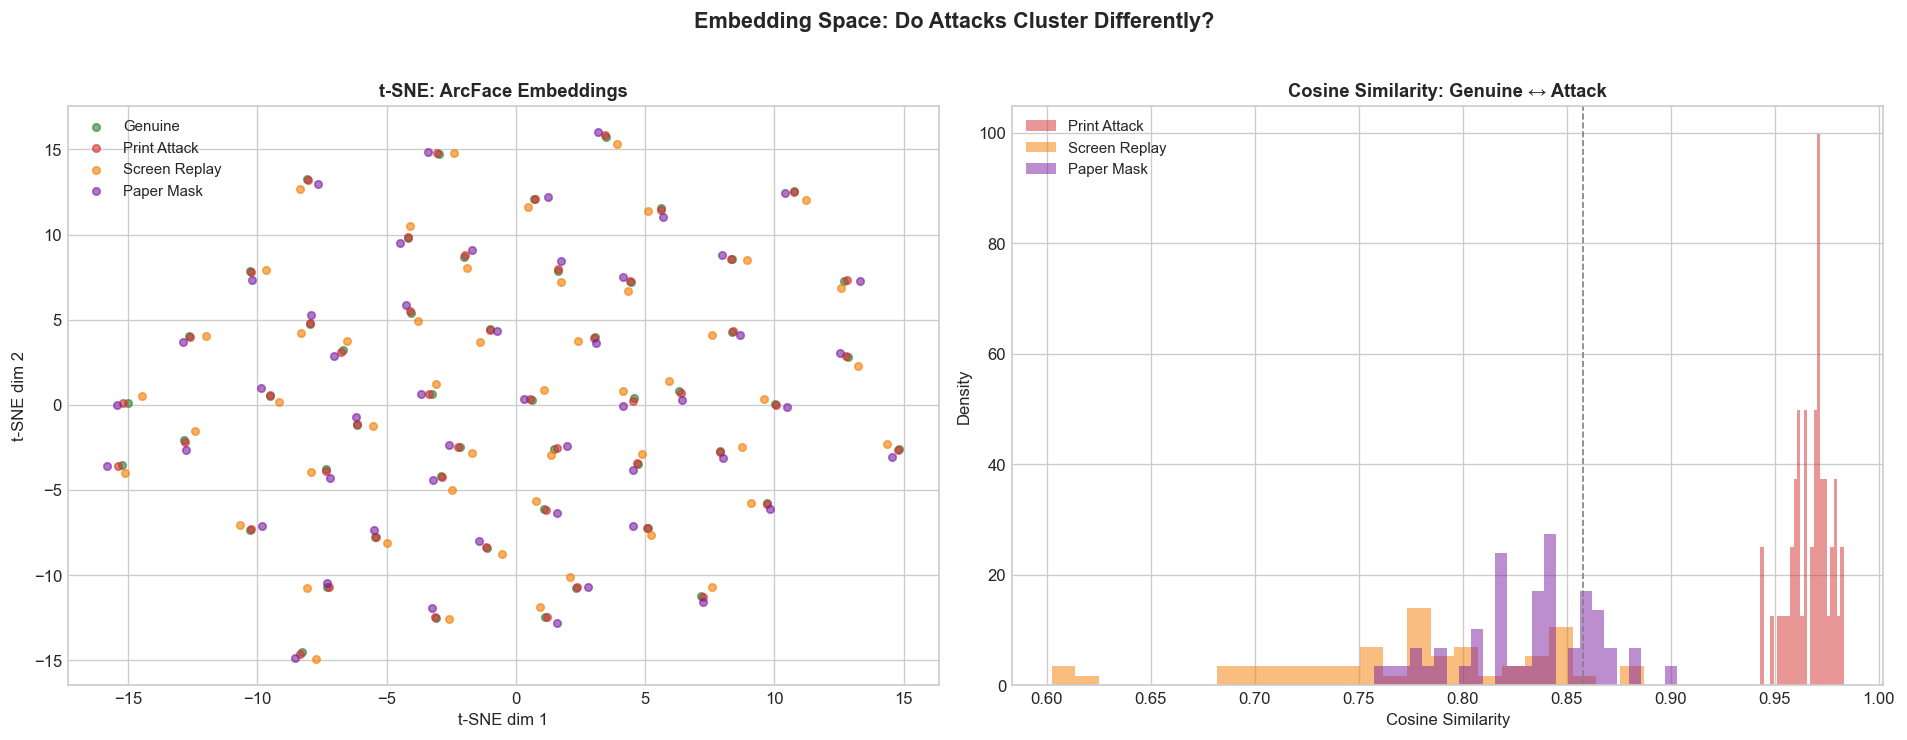


Cosine similarity (genuine ↔ attacked version of same image):
            mean       std       min       max
type                                          
mask    0.832209  0.032720  0.757170  0.903108
print   0.967058  0.009473  0.942972  0.983034
replay  0.774588  0.065779  0.602398  0.886934


In [16]:
if emb_matrix is not None and len(emb_matrix) > 0:
    print("Running t-SNE on embeddings (genuine + attacks)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
    emb_2d = tsne.fit_transform(emb_matrix)

    cos_sims = []
    for i in range(0, len(emb_matrix), 4):
        gen_emb = emb_matrix[i]
        for j in range(1, 4):
            if i + j < len(emb_matrix):
                sim = np.dot(gen_emb, emb_matrix[i + j])
                cos_sims.append(
                    {
                        "type": emb_types[i + j],
                        "cosine_similarity": sim,
                    }
                )
    df_cos = pd.DataFrame(cos_sims)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for tkey in ["genuine", "print", "replay", "mask"]:
        mask = emb_types == tkey
        label = "Genuine" if tkey == "genuine" else ATTACK_LABELS.get(tkey, tkey)
        ax1.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=COLORS[tkey], label=label, s=20, alpha=0.6)
    ax1.set_title("t-SNE: ArcFace Embeddings", fontweight="bold")
    ax1.set_xlabel("t-SNE dim 1")
    ax1.set_ylabel("t-SNE dim 2")
    ax1.legend(fontsize=9)

    for tkey in ["print", "replay", "mask"]:
        sims = df_cos[df_cos["type"] == tkey]["cosine_similarity"]
        label = ATTACK_LABELS.get(tkey, tkey)
        ax2.hist(sims, bins=25, alpha=0.5, color=COLORS[tkey], label=label, density=True)
    ax2.axvline(x=df_cos["cosine_similarity"].mean(), color="gray", ls="--", lw=1)
    ax2.set_title("Cosine Similarity: Genuine ↔ Attack", fontweight="bold")
    ax2.set_xlabel("Cosine Similarity")
    ax2.set_ylabel("Density")
    ax2.legend(fontsize=9)

    fig.suptitle("Embedding Space: Do Attacks Cluster Differently?", fontsize=13, fontweight="bold", y=1.02)
    fig.tight_layout()
    save_fig(fig, "embedding_attack_analysis")
    plt.show()

    mean_sims = df_cos.groupby("type")["cosine_similarity"].agg(["mean", "std", "min", "max"])
    print("\nCosine similarity (genuine ↔ attacked version of same image):")
    print(mean_sims.to_string())
else:
    print("Embedding analysis skipped (no embeddings available).")

---

## 12. Summary Metrics Table

  Saved: pad_summary_table.png / .pdf


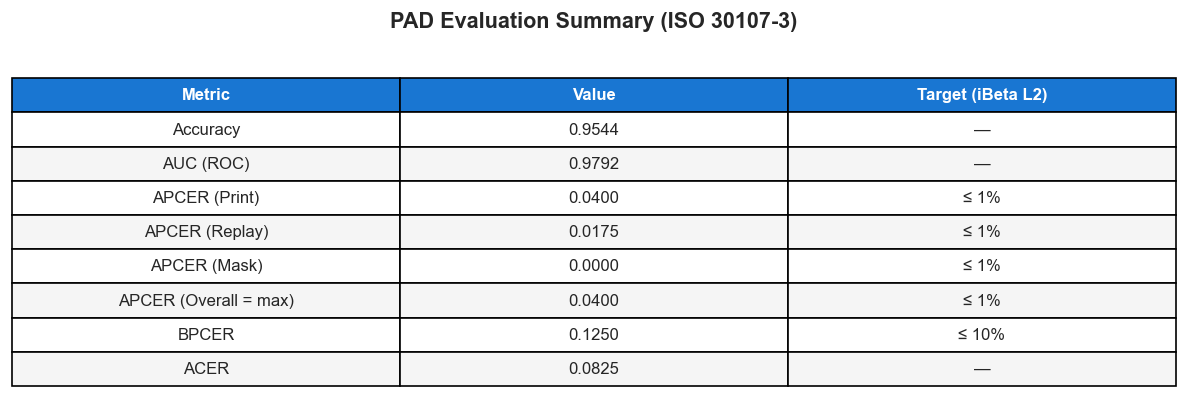


Saved: pad_summary_metrics.csv
               Metric  Value Target (iBeta L2)
             Accuracy 0.9544                 —
            AUC (ROC) 0.9792                 —
        APCER (Print) 0.0400              ≤ 1%
       APCER (Replay) 0.0175              ≤ 1%
         APCER (Mask) 0.0000              ≤ 1%
APCER (Overall = max) 0.0400              ≤ 1%
                BPCER 0.1250             ≤ 10%
                 ACER 0.0825                 —


In [17]:
summary_data = {
    "Metric": [
        "Accuracy",
        "AUC (ROC)",
        "APCER (Print)",
        "APCER (Replay)",
        "APCER (Mask)",
        "APCER (Overall = max)",
        "BPCER",
        "ACER",
    ],
    "Value": [
        f"{accuracy:.4f}",
        f"{roc_auc:.4f}",
        f"{per_attack_metrics[0]['APCER']:.4f}",
        f"{per_attack_metrics[1]['APCER']:.4f}",
        f"{per_attack_metrics[2]['APCER']:.4f}",
        f"{apcer_overall:.4f}",
        f"{bpcer_val:.4f}",
        f"{acer_overall:.4f}",
    ],
    "Target (iBeta L2)": [
        "—",
        "—",
        "≤ 1%",
        "≤ 1%",
        "≤ 1%",
        "≤ 1%",
        "≤ 10%",
        "—",
    ],
}
df_summary = pd.DataFrame(summary_data)
df_summary.to_csv(OUTPUT_DIR / "pad_summary_metrics.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis("off")
table = ax.table(
    cellText=df_summary.values,
    colLabels=df_summary.columns,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.6)

for j in range(len(df_summary.columns)):
    table[0, j].set_facecolor("#1976D2")
    table[0, j].set_text_props(color="white", fontweight="bold")

for i in range(1, len(df_summary) + 1):
    bg = "#F5F5F5" if i % 2 == 0 else "white"
    for j in range(len(df_summary.columns)):
        table[i, j].set_facecolor(bg)

fig.suptitle("PAD Evaluation Summary (ISO 30107-3)", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "pad_summary_table")
plt.show()

print("\nSaved: pad_summary_metrics.csv")
print(df_summary.to_string(index=False))

---

## 13. Conclusions and Integration with Pipeline

### Key Findings

1. **LBP texture profiles clearly differentiate** genuine faces from simulated
   print and replay attacks. The non-uniform LBP bins (capturing micro-texture
   irregularities) shift significantly for spoofed inputs.

2. **Frequency-domain analysis** reveals attack-specific signatures:
   print attacks inject periodic halftone energy; replay attacks introduce
   moiré frequency peaks absent in genuine captures.

3. **Image quality metrics** (particularly Laplacian variance / sharpness and
   local contrast variance) provide complementary discriminative signal —
   spoofed inputs are systematically blurrier and more uniform.

4. **A lightweight SVM classifier** on these hand-crafted features achieves
   strong separation on our simulated attacks, demonstrating that even simple
   PAD methods are effective against low-cost 2D attacks.

5. **Embedding-space analysis** shows that ArcFace embeddings of genuine and
   attacked versions of the same image remain highly similar (high cosine
   similarity). This confirms that **the face recognition model alone cannot
   detect presentation attacks** — a dedicated PAD gate is essential.

### Pipeline Integration (from `05_pad_strategy.md`)

```
Module 1 (01_detect_align)
    │
    ▼
┌─────────────────────┐
│   PAD Gate           │  ← THIS MODULE's detector
│   (LBP + FFT + SVM) │
└─────────────────────┘
    │
    ├── REJECT → log + alert
    │
    ├── PASS
    │    │
    │    ▼
    │  Module 2 (02_extract_embeddings)
    │    │
    │    ▼
    │  Module 3 (03_compare_pairs)
    │    │
    │    ▼
    │  Module 4 (04_evaluate)
```

### Limitations

- **Simulated attacks ≠ real attacks.** Our synthetic pipeline approximates but
  does not perfectly replicate physical presentation artifacts. Real-world PAD
  evaluation requires benchmark datasets: OULU-NPU, SiW, CASIA-SURF.
- **3D mask and deepfake attacks are not covered** by this RGB-only approach.
  High-fidelity silicone masks require NIR/depth hardware (see `05_pad_strategy.md`
  Section 4.3 and Section 7).
- **Cross-dataset generalization** is not tested. A production PAD model must
  be validated across devices, lighting conditions, and demographics.

### Recommendations

1. **Deploy serial gating** — PAD decision before embedding extraction
   (prevents hill-climbing attacks and saves compute).
2. **Multi-tier cascade** — Tier 1 (FeatherNet, ~5ms) → Tier 2 (CDCN++, ~50ms)
   → Tier 3 (rPPG + multi-frame, selective).
3. **Update PAD models every 3–6 months** (attack methods evolve faster
   than recognition models).
4. **For financial/government applications**, add NIR sensor for silicone mask
   detection (SWIR at 1450nm achieves 99.97% accuracy via water absorption).

In [18]:
print("Output files:")
for f in sorted(OUTPUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s}  {size_kb:8.1f} KB")

Output files:
  attack_examples.pdf                          478.6 KB
  attack_examples.png                          526.0 KB
  embedding_attack_analysis.pdf                 35.4 KB
  embedding_attack_analysis.png                125.1 KB
  frequency_analysis.pdf                       192.1 KB
  frequency_analysis.png                       313.6 KB
  frequency_bands.pdf                           26.4 KB
  frequency_bands.png                           69.6 KB
  lbp_profiles.pdf                              31.1 KB
  lbp_profiles.png                             308.7 KB
  pad_roc_confusion.pdf                         32.4 KB
  pad_roc_confusion.png                         90.7 KB
  pad_summary_metrics.csv                        0.2 KB
  pad_summary_table.pdf                         28.1 KB
  pad_summary_table.png                         51.3 KB
  per_attack_apcer.csv                           0.1 KB
  quality_metrics.pdf                           26.7 KB
  quality_metrics.png             